# 06 - Calibration - Task 14.7

Convert the stress distributions from 14.6 into the 8 PARTIAL parameters from spec §8 / §10:

| # | Parameter | How |
|---|-----------|-----|
| 1 | `c_min` | bisect c so `P(ruin) <= 0.1%` under severe crash + bootstrap fund |
| 2 | `floor_curve` | placeholder single-sigma; multi-sigma fit deferred |
| 3 | `fee_curve` (refit) | bisect fee so median fund-P&L = 0 at `c_min` |
| 4 | `breakers` (L0/L1/L2/L3) | heuristic health-ratio bands |
| 5 | `withdrawal_delay` | heuristic 7d |
| 6 | `exposure_caps` | book-size sweep; largest with `P(ruin) <= 0.1%` |
| 7 | `first_loss` | heuristic 2% of PARTIAL notional |
| 8 | `fund_target` | `-quantile(fund_pnl, ruin_budget)` at `c_min` |

Architecture: build a per-swap `_ScenarioCache` ONCE, then every calibrator re-evaluates the waterfall in pure numpy. The vectorised payout/max_il helper agrees with `il.compute_payout` to 1e-9 (test `test_vectorised_matches_il_module_per_position`). Result is a `CalibrationResult` dataclass that Task 14.8 will serialise to `quant/params.json`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from inflexion_quant.calibrate import (
    build_scenario_cache, fund_pnl_from_cache,
    calibrate_c_min, calibrate_fund_target, calibrate_fee_curve,
    calibrate_exposure_caps, calibrate_all,
)
from inflexion_quant.portfolio import default_fee_curve
from inflexion_quant.stress import CorrelatedCrashConfig, correlated_crash_terminal_fn, ruin_probability

plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': 0.3})

N_RUNS = 1000
N_POSITIONS = 200
RNG_SEED = 20260527
PREMIUM_RATE = 0.75
PREMIUM_SHARE = 0.20
RUIN_BUDGET = 0.001

## A. Build the scenario cache once

Severe correlated crash, 1000 runs x 200 positions. After this all calibrators run in vector ops (~ms).

In [2]:
cfg = CorrelatedCrashConfig.severe()
cache = build_scenario_cache(
    n_runs=N_RUNS, n_positions=N_POSITIONS,
    terminal_fn=correlated_crash_terminal_fn(cfg),
    rng=np.random.default_rng(RNG_SEED), P0=100.0,
)
typical_book_notional = float(np.median(cache.V0s.sum(axis=1)))
print(f'Cache: {cache.n_runs} runs x {cache.n_positions} positions')
print(f'Median book notional (sum V0): ${typical_book_notional:,.0f}')

Cache: 1000 runs x 200 positions
Median book notional (sum V0): $2,966,326


## B. c_min vs fund balance

Smallest c that keeps `P(ruin) <= ruin_budget` for each candidate fund balance. The curve is monotone: more equity in the fund -> can survive a lower c. The protocol picks `c_min` at the chosen fund-equity bootstrap (5% of book notional).

In [3]:
balance_grid = typical_book_notional * np.array([0.01, 0.02, 0.05, 0.10, 0.20, 0.50])
rows = []
for bal in balance_grid:
    res = calibrate_c_min(cache=cache, fund_balance=float(bal), ruin_budget=RUIN_BUDGET, premium_rate=PREMIUM_RATE, premium_share=PREMIUM_SHARE)
    rows.append({'fund_balance': bal, 'fund_balance_pct': bal / typical_book_notional, **res})
c_min_sweep = pd.DataFrame(rows)
c_min_sweep

,fund_balance,fund_balance_pct,c_min,ruin_at_c_min,feasible
0,2.966326e+04,0.01,0.02,0.0,True
1,5.932652e+04,0.02,0.02,0.0,True
2,1.483163e+05,0.05,0.02,0.0,True
3,2.966326e+05,0.10,0.02,0.0,True
4,5.932652e+05,0.20,0.02,0.0,True
5,1.483163e+06,0.50,0.02,0.0,True


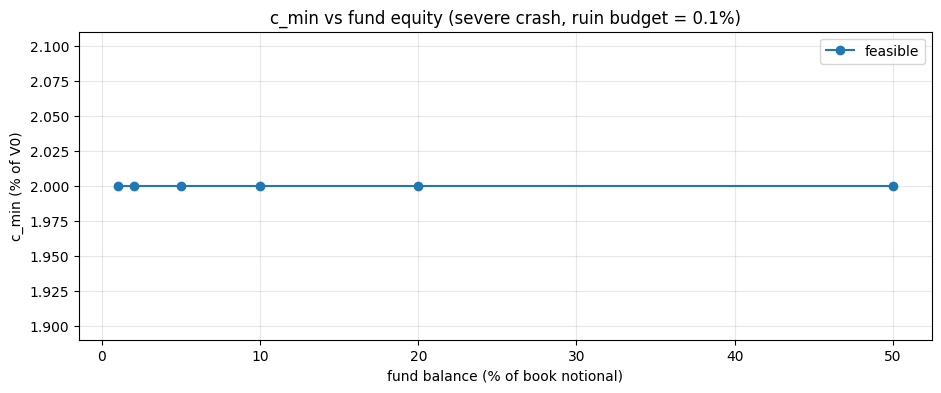

In [4]:
fig, ax = plt.subplots()
feasible = c_min_sweep[c_min_sweep['feasible']]
infeas = c_min_sweep[~c_min_sweep['feasible']]
ax.plot(feasible['fund_balance_pct'] * 100, feasible['c_min'] * 100, marker='o', label='feasible')
if not infeas.empty:
    ax.scatter(infeas['fund_balance_pct'] * 100, [50] * len(infeas), marker='x', color='red', s=80, label='infeasible (c_min > 50%)')
ax.set_xlabel('fund balance (% of book notional)')
ax.set_ylabel('c_min (% of V0)')
ax.set_title(f'c_min vs fund equity (severe crash, ruin budget = {RUIN_BUDGET * 100:.1f}%)')
ax.legend(); plt.show()

## C. fund_target at c_min

At c_min calibrated against the 5%-of-notional bootstrap, the exact equity needed to keep `P(ruin) <= ruin_budget` is `-quantile(fund_pnl, ruin_budget)`. Plot the fund-P&L distribution with the budget cutoff.

c_min:               2.00%   (bootstrap fund = $148,316)
fund_target:         $0
CVaR@ruin_budget:    $-110,865
median fund_pnl:     $247,826


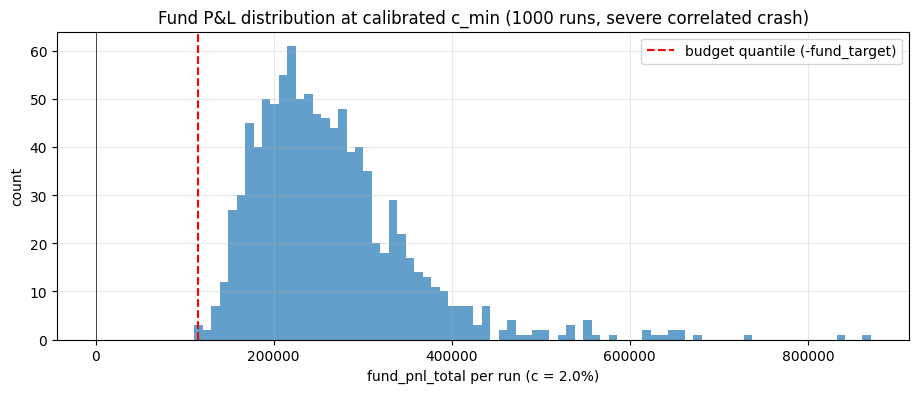

In [5]:
bootstrap_balance = 0.05 * typical_book_notional
c_res = calibrate_c_min(cache=cache, fund_balance=bootstrap_balance, ruin_budget=RUIN_BUDGET)
c_min = c_res['c_min']
fund_res = calibrate_fund_target(cache=cache, c=c_min, ruin_budget=RUIN_BUDGET)
print(f'c_min:               {c_min * 100:.2f}%   (bootstrap fund = ${bootstrap_balance:,.0f})')
print(f'fund_target:         ${fund_res["fund_target"]:,.0f}')
print(f'CVaR@ruin_budget:    ${fund_res["cvar_at_budget"]:,.0f}')
print(f'median fund_pnl:     ${fund_res["median_pnl"]:,.0f}')

pnl = fund_pnl_from_cache(cache, c=c_min, premium_rate=PREMIUM_RATE, premium_share=PREMIUM_SHARE)
fig, ax = plt.subplots()
ax.hist(pnl, bins=80, alpha=0.7)
ax.axvline(0, color='k', lw=0.5)
ax.axvline(np.quantile(pnl, RUIN_BUDGET), color='red', linestyle='--', label=f'budget quantile (-fund_target)')
ax.set_xlabel(f'fund_pnl_total per run (c = {c_min * 100:.1f}%)')
ax.set_ylabel('count')
ax.set_title(f'Fund P&L distribution at calibrated c_min ({N_RUNS} runs, severe correlated crash)')
ax.legend(); plt.show()

## D. Fee curve refit

The placeholder `fee(c) = 1% * (0.20/c)^2.32` is anchored at spec §8.3 illustrative pivots. The refit (bisection over the fee scalar `f` such that median fund_pnl >= 0) tells us whether the placeholder under-prices the tail at the calibrated c_min.

In [6]:
fee_res = calibrate_fee_curve(cache=cache, c=c_min, premium_rate=PREMIUM_RATE, premium_share=PREMIUM_SHARE)
print('--- Fee curve refit at c_min ---')
for k, v in fee_res.items():
    if isinstance(v, float):
        print(f'  {k:>26}: {v:>10.5f}')
    else:
        print(f'  {k:>26}: {v}')

--- Fee curve refit at c_min ---
         fee_ref_recommended:    0.00146
                fee_pct_at_c:    0.30522
    placeholder_fee_pct_at_c:    2.08930
                       c_ref:    0.20000
                    exponent:    2.32000
         median_pnl_at_refit:    0.02567
      feasible_in_fee_search: True


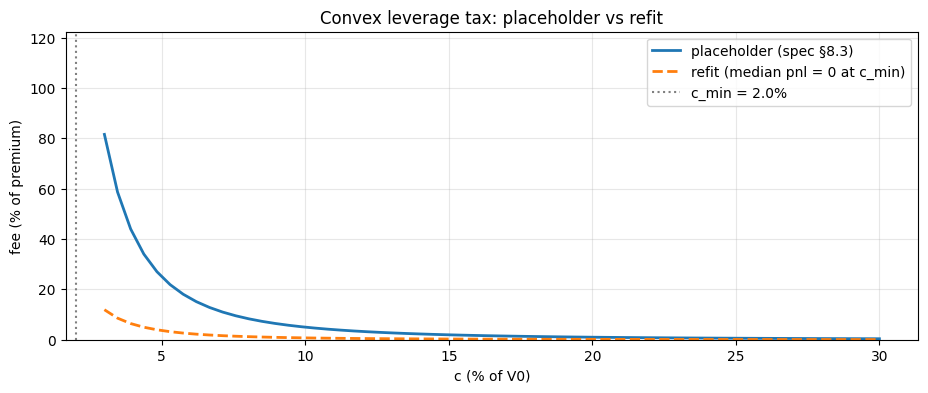

In [7]:
c_grid = np.linspace(0.03, 0.30, 60)
placeholder = np.array([default_fee_curve(c) for c in c_grid])
exponent = fee_res['exponent']
c_ref = fee_res['c_ref']
refit_ref = fee_res['fee_ref_recommended']
refit = refit_ref * (c_ref / c_grid) ** exponent if refit_ref > 0 else np.zeros_like(c_grid)

fig, ax = plt.subplots()
ax.plot(c_grid * 100, placeholder * 100, lw=2, label='placeholder (spec §8.3)')
ax.plot(c_grid * 100, refit * 100, lw=2, linestyle='--', label='refit (median pnl = 0 at c_min)')
ax.axvline(c_min * 100, color='gray', linestyle=':', label=f'c_min = {c_min * 100:.1f}%')
ax.set_xlabel('c (% of V0)')
ax.set_ylabel('fee (% of premium)')
ax.set_title('Convex leverage tax: placeholder vs refit')
ax.legend(); ax.set_ylim(0, max(50, placeholder[0] * 100 * 1.5))
plt.show()

## E. Exposure caps (per-market book-size sweep)

For the calibrated c_min and fund_target, what's the largest book size that still clears `P(ruin) <= 0.1%`? Beyond this we'd need to scale the fund, not the book.

In [8]:
exposure_res = calibrate_exposure_caps(
    fund_balance=fund_res['fund_target'], c=c_min,
    n_positions_grid=np.array([50, 100, 200, 400, 700, 1000]),
    n_runs=500, cfg=cfg, rng_seed=RNG_SEED,
    premium_rate=PREMIUM_RATE, premium_share=PREMIUM_SHARE,
    ruin_budget=RUIN_BUDGET,
)
print(f'per_market_cap: {exposure_res["per_market_cap"]} swaps')
print(f'per_mm_cap:     {exposure_res["per_mm_cap"]} swaps  (= per_market / {exposure_res["n_mms_per_market"]})')
pd.DataFrame(exposure_res['sweep'])

per_market_cap: 1000 swaps
per_mm_cap:     200 swaps  (= per_market / 5)


,n_positions,ruin_p,var_99,cvar_99
0,50,0.0,-21382.518410,-20109.229970
1,100,0.0,-56820.796530,-52200.480761
2,200,0.0,-134149.280044,-124597.844416
3,400,0.0,-308119.098986,-297932.062407
4,700,0.0,-595323.788652,-576678.045194
5,1000,0.0,-886377.461957,-853392.360858


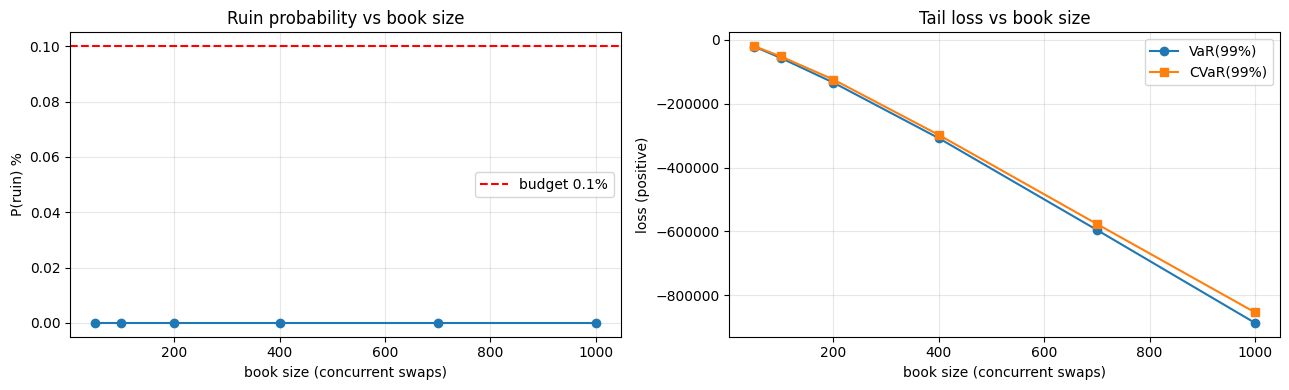

In [9]:
sweep_df = pd.DataFrame(exposure_res['sweep'])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sweep_df['n_positions'], sweep_df['ruin_p'] * 100, marker='o')
axes[0].axhline(RUIN_BUDGET * 100, color='red', linestyle='--', label=f'budget {RUIN_BUDGET * 100:.1f}%')
axes[0].set_xlabel('book size (concurrent swaps)')
axes[0].set_ylabel('P(ruin) %')
axes[0].set_title('Ruin probability vs book size')
axes[0].legend()
axes[1].plot(sweep_df['n_positions'], sweep_df['var_99'], marker='o', label='VaR(99%)')
axes[1].plot(sweep_df['n_positions'], sweep_df['cvar_99'], marker='s', label='CVaR(99%)')
axes[1].set_xlabel('book size (concurrent swaps)')
axes[1].set_ylabel('loss (positive)')
axes[1].set_title('Tail loss vs book size')
axes[1].legend()
plt.tight_layout(); plt.show()

## F. Run the full calibration -> CalibrationResult

Top-level orchestrator that runs all 8 calibrations end-to-end. Output is a `CalibrationResult` dataclass — exactly what Task 14.8 will serialise to `params.json`.

In [10]:
result = calibrate_all(
    n_runs=N_RUNS, n_positions=N_POSITIONS,
    premium_rate=PREMIUM_RATE, premium_share=PREMIUM_SHARE,
    ruin_budget=RUIN_BUDGET, rng_seed=RNG_SEED,
)
import json
print(json.dumps(result.to_dict(), indent=2, default=str))

{
  "c_min": 0.02,
  "floor_curve": {
    "c_at_baseline_vol": 0.02,
    "note": "single-vol calibration; multi-\u03c3 fit deferred to post-hack (Phase 15 calibration sweep)"
  },
  "fee_curve": {
    "fee_ref_recommended": 0.0014608822230117399,
    "fee_pct_at_c": 0.3052215576171875,
    "placeholder_fee_pct_at_c": 2.0892961308540388,
    "c_ref": 0.2,
    "exponent": 2.32,
    "median_pnl_at_refit": 0.025674219283246202,
    "feasible_in_fee_search": true
  },
  "breakers": {
    "L0": 1.0,
    "L1": 0.7,
    "L2": 0.4,
    "L3": 0.0
  },
  "withdrawal_delay_seconds": 604800,
  "exposure_caps": {
    "per_market_cap": 1000,
    "per_mm_cap": 200,
    "n_mms_per_market": 5
  },
  "first_loss_fraction": 0.02,
  "fund_target": 0.0,
  "ruin_budget": 0.001,
  "c_used_for_fund_target": 0.02,
  "n_runs": 1000,
  "n_positions": 200,
  "notes": "Calibrated against CorrelatedCrashConfig (severe) on 1000 runs \u00d7 200 positions with rng_seed=20260527. Heuristics: breakers (ratios), withdrawa

## G. Next

**Task 14.8 - `quant/params.json`.** Take this `CalibrationResult` and emit a versioned, schema-validated JSON file. The on-chain `InsuranceVault.sol` (Phase 15) and the off-chain matcher both read from it; the `notes` field carries the provenance (n_runs, rng_seed, stress config). One CI test reloads the file and assert-roundtrips it; another rejects any PR that hardcodes a PARTIAL constant outside `params.json`.